In [6]:
import pandas as pd

df = pd.read_csv("metrics_long.csv")

df = df.rename(columns={
    "MRE(%)": "MRE_pct"
})



In [7]:
summary = (
    df.groupby("learner")[["R2", "MAE", "RMSE", "MRE_pct"]]
      .agg(["mean", "std"])
      .round(4)
)


In [8]:
pivot = (
    df.pivot_table(
        index="model_tag",
        columns="learner",
        values="R2",
        aggfunc="mean"
    )
    .round(4)
)

pivot


learner,llm_pilot,lr,nn,rf_light,ridge
model_tag,,,,,
data_EleutherAI_gpt-neox-20b,0.0139,0.0759,0.1123,0.1150,0.0759
data_Salesforce_codegen2-16B,-0.0001,0.0643,0.1465,0.1675,0.0643
data_bigcode_starcoder,0.0205,0.0753,0.1096,0.1114,0.0753
data_bigscience_mt0-xxl,0.0072,0.1005,0.1834,0.1788,0.1005
data_google_flan-t5-xl,0.0118,0.0734,0.1184,0.1162,0.0734
data_google_flan-t5-xxl,0.0092,0.0779,0.1274,0.1267,0.0779
data_google_flan-ul2,0.0055,0.0661,0.1057,0.1067,0.0661
data_ibm_mpt-7b-instruct2,0.0078,0.0813,0.1603,0.1900,0.0813
data_llama-13b,0.0185,0.0761,0.1173,0.1184,0.0761


<Figure size 640x480 with 0 Axes>

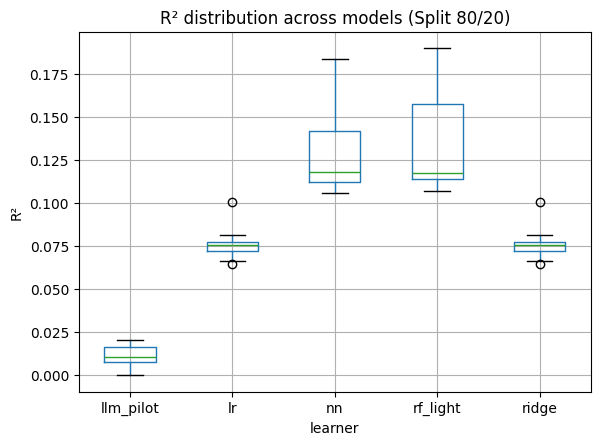

In [9]:
import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column="R2", by="learner")
plt.title("R² distribution across models (Split 80/20)")
plt.suptitle("")
plt.ylabel("R²")
plt.show()


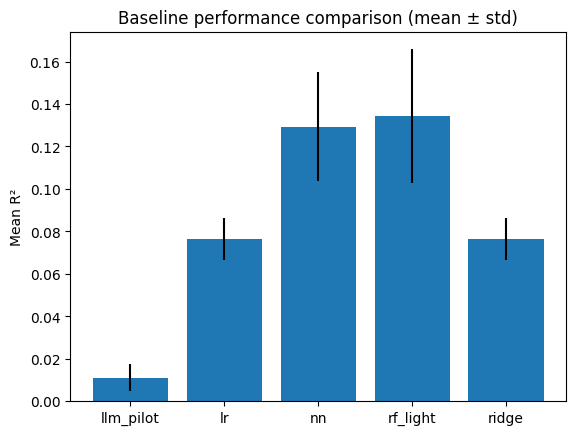

In [10]:
stats = (
    df.groupby("learner")["R2"]
      .agg(["mean", "std"])
)

plt.figure()
plt.bar(stats.index, stats["mean"], yerr=stats["std"])
plt.ylabel("Mean R²")
plt.title("Baseline performance comparison (mean ± std)")
plt.show()


In [11]:
r2_table = (
    df.pivot_table(
        index="model_tag",
        columns="learner",
        values="R2",
        aggfunc="mean"
    )
    .round(4)
)

r2_table


learner,llm_pilot,lr,nn,rf_light,ridge
model_tag,,,,,
data_EleutherAI_gpt-neox-20b,0.0139,0.0759,0.1123,0.1150,0.0759
data_Salesforce_codegen2-16B,-0.0001,0.0643,0.1465,0.1675,0.0643
data_bigcode_starcoder,0.0205,0.0753,0.1096,0.1114,0.0753
data_bigscience_mt0-xxl,0.0072,0.1005,0.1834,0.1788,0.1005
data_google_flan-t5-xl,0.0118,0.0734,0.1184,0.1162,0.0734
data_google_flan-t5-xxl,0.0092,0.0779,0.1274,0.1267,0.0779
data_google_flan-ul2,0.0055,0.0661,0.1057,0.1067,0.0661
data_ibm_mpt-7b-instruct2,0.0078,0.0813,0.1603,0.1900,0.0813
data_llama-13b,0.0185,0.0761,0.1173,0.1184,0.0761


In [12]:
mae_table = (
    df.pivot_table(
        index="model_tag",
        columns="learner",
        values="MAE",
        aggfunc="mean"
    )
    .round(4)
)

mae_table


learner,llm_pilot,lr,nn,rf_light,ridge
model_tag,,,,,
data_EleutherAI_gpt-neox-20b,235.7329,227.4105,204.1043,208.1902,227.4096
data_Salesforce_codegen2-16B,167.8564,162.8358,127.4660,120.8024,162.8243
data_bigcode_starcoder,243.3180,240.5404,224.9447,220.4172,240.5401
data_bigscience_mt0-xxl,242.5048,236.0100,202.0601,200.9645,236.0013
data_google_flan-t5-xl,169.7300,165.9638,144.5941,147.9680,165.9635
data_google_flan-t5-xxl,161.0509,156.0758,135.6982,138.3489,156.0751
data_google_flan-ul2,142.7763,139.8003,128.0532,125.7187,139.7988
data_ibm_mpt-7b-instruct2,326.1499,316.7611,260.6267,249.5939,316.7545
data_llama-13b,254.1890,247.8297,229.6452,223.1184,247.8292


In [13]:
rmse_table = (
    df.pivot_table(
        index="model_tag",
        columns="learner",
        values="RMSE",
        aggfunc="mean"
    )
    .round(4)
)

rmse_table


learner,llm_pilot,lr,nn,rf_light,ridge
model_tag,,,,,
data_EleutherAI_gpt-neox-20b,580.0611,561.5371,550.3652,549.5310,561.5371
data_Salesforce_codegen2-16B,420.7341,406.9640,388.6662,383.8667,406.9637
data_bigcode_starcoder,595.3047,578.3998,567.5599,567.0102,578.3998
data_bigscience_mt0-xxl,513.5787,488.8542,465.7843,467.1114,488.8543
data_google_flan-t5-xl,428.1601,414.6015,404.4140,404.9102,414.6015
data_google_flan-t5-xxl,402.7061,388.4963,377.9246,378.0861,388.4963
data_google_flan-ul2,358.3040,347.2280,339.7776,339.5869,347.2280
data_ibm_mpt-7b-instruct2,768.0906,739.1117,706.6373,694.0244,739.1115
data_llama-13b,642.5164,623.3835,609.3305,608.9657,623.3835


In [14]:
mre_table = (
    df.pivot_table(
        index="model_tag",
        columns="learner",
        values="MRE_pct",
        aggfunc="mean"
    )
    .round(4)
)

mre_table


learner,llm_pilot,lr,nn,rf_light,ridge
model_tag,,,,,
data_EleutherAI_gpt-neox-20b,462.6393,439.4304,165.4973,176.7804,439.4228
data_Salesforce_codegen2-16B,1946.7850,1228.6312,304.1568,276.5350,1228.3128
data_bigcode_starcoder,340.4480,290.3896,183.5023,172.0224,290.3881
data_bigscience_mt0-xxl,746.0630,507.4973,150.6288,158.9932,507.4297
data_google_flan-t5-xl,689.6614,463.1908,171.2504,187.5233,463.1863
data_google_flan-t5-xxl,820.2815,569.3855,186.8171,189.3515,569.3763
data_google_flan-ul2,657.0933,424.8363,205.5691,187.2992,424.8209
data_ibm_mpt-7b-instruct2,1709.2590,1191.2872,213.1052,194.5472,1191.1808
data_llama-13b,437.3915,355.5621,180.0135,168.9034,355.5598


In [15]:
metrics = ["R2", "MAE", "RMSE", "MRE_pct"]

combined = (
    df.set_index(["model_tag", "learner"])[metrics]
      .unstack("learner")
      .round(4)
)

combined


R2                                   \
learner                      llm_pilot      lr      nn rf_light   ridge   
model_tag                                                                 
data_EleutherAI_gpt-neox-20b    0.0139  0.0759  0.1123   0.1150  0.0759   
data_Salesforce_codegen2-16B   -0.0001  0.0643  0.1465   0.1675  0.0643   
data_bigcode_starcoder          0.0205  0.0753  0.1096   0.1114  0.0753   
data_bigscience_mt0-xxl         0.0072  0.1005  0.1834   0.1788  0.1005   
data_google_flan-t5-xl          0.0118  0.0734  0.1184   0.1162  0.0734   
data_google_flan-t5-xxl         0.0092  0.0779  0.1274   0.1267  0.0779   
data_google_flan-ul2            0.0055  0.0661  0.1057   0.1067  0.0661   
data_ibm_mpt-7b-instruct2       0.0078  0.0813  0.1603   0.1900  0.0813   
data_llama-13b                  0.0185  0.0761  0.1173   0.1184  0.0761   
data_llama-7b                   0.0169  0.0718  0.1124   0.1131  0.0718   

                                   MAE                                \
learner                      llm_pilot        lr        nn  rf_light   
model_tag                                                              
data_EleutherAI_gpt-neox-20b  235.7329  227.4105  204.1043  208.1902   
data_Salesforce_codegen2-16B  167.8564  162.8358  127.4660  120.8024   
data_bigcode_starcoder        243.3180  240.5404  224.9447  220.4172   
data_bigscience_mt0-xxl       242.5048  236.0100  202.0601  200.9645   
data_google_flan-t5-xl        169.7300  165.9638  144.5941  147.9680   
data_google_flan-t5-xxl       161.0509  156.0758  135.6982  138.3489   
data_google_flan-ul2          142.7763  139.8003  128.0532  125.7187   
data_ibm_mpt-7b-instruct2     326.1499  316.7611  260.6267  249.5939   
data_llama-13b                254.1890  247.8297  229.6452  223.1184   
data_llama-7b                 312.8501  307.9114  273.0459  277.0641   

                                            RMSE                      \
learner                          ridge llm_pilot        lr        nn   
model_tag                                                              
data_EleutherAI_gpt-neox-20b  227.4096  580.0611  561.5371  550.3652   
data_Salesforce_codegen2-16B  162.8243  420.7341  406.9640  388.6662   
data_bigcode_starcoder        240.5401  595.3047  578.3998  567.5599   
data_bigscience_mt0-xxl       236.0013  513.5787  488.8542  465.7843   
data_google_flan-t5-xl        165.9635  428.1601  414.6015  404.4140   
data_google_flan-t5-xxl       156.0751  402.7061  388.4963  377.9246   
data_google_flan-ul2          139.7988  358.3040  347.2280  339.7776   
data_ibm_mpt-7b-instruct2     316.7545  768.0906  739.1117  706.6373   
data_llama-13b                247.8292  642.5164  623.3835  609.3305   
data_llama-7b                 307.9110  798.4629  775.8482  758.6984   

                                                    MRE_pct             \
learner                       rf_light     ridge  llm_pilot         lr   
model_tag                                                                
data_EleutherAI_gpt-neox-20b  549.5310  561.5371   462.6393   439.4304   
data_Salesforce_codegen2-16B  383.8667  406.9637  1946.7850  1228.6312   
data_bigcode_starcoder        567.0102  578.3998   340.4480   290.3896   
data_bigscience_mt0-xxl       467.1114  488.8543   746.0630   507.4973   
data_google_flan-t5-xl        404.9102  414.6015   689.6614   463.1908   
data_google_flan-t5-xxl       378.0861  388.4963   820.2815   569.3855   
data_google_flan-ul2          339.5869  347.2280   657.0933   424.8363   
data_ibm_mpt-7b-instruct2     694.0244  739.1115  1709.2590  1191.2872   
data_llama-13b                608.9657  623.3835   437.3915   355.5621   
data_llama-7b                 758.3800  775.8482   422.5062   332.9730   

                                                             
learner                             nn  rf_light      ridge  
model_tag                                                    
data_EleutherAI_gpt-neox-20b  165.497

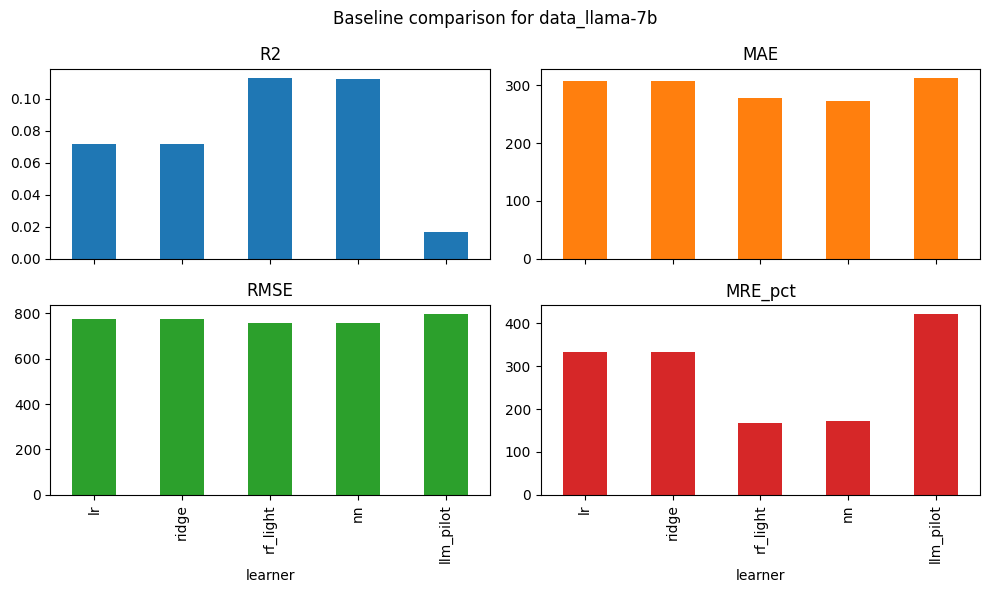

In [16]:
model = "data_llama-7b"

subset = df[df["model_tag"] == model]

subset.plot(
    x="learner",
    y=["R2", "MAE", "RMSE", "MRE_pct"],
    kind="bar",
    subplots=True,
    layout=(2,2),
    figsize=(10,6),
    legend=False
)

plt.suptitle(f"Baseline comparison for {model}")
plt.tight_layout()
plt.show()


In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Load ----------
df = pd.read_csv("metrics_long.csv")
df = df.rename(columns={"MRE(%)": "MRE_pct"})

# If you have multiple targets, filter to the one you want (recommended)
# df = df[df["target"] == "Target_throughput_tokens_per_sec"]

# Output folder
out_dir = "visual/per_model_figs"
os.makedirs(out_dir, exist_ok=True)

# Metrics to plot (title, column, higher_is_better)
metrics = [
    ("R²", "R2", True),
    ("MAE", "MAE", False),
    ("RMSE", "RMSE", False),
    ("MRE (%)", "MRE_pct", False),
]

# Ensure consistent learner order (optional)
learner_order = ["lr", "ridge", "rf_light", "nn", "llm_pilot"]
# Keep only those present in your dataframe
learner_order = [l for l in learner_order if l in set(df["learner"].astype(str))]

# ---------- Plot per model ----------
for model_tag, g in df.groupby("model_tag"):
    # aggregate in case you have multiple rows per learner (e.g., repeated runs)
    agg = (
        g.groupby("learner")[["R2", "MAE", "RMSE", "MRE_pct"]]
         .mean()
         .reindex(learner_order)
    )

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for i, (title, col, _) in enumerate(metrics):
        ax = axes[i]
        y = agg[col].dropna()

        ax.bar(y.index, y.values)  # no manual colors
        ax.set_title(title)
        ax.set_xlabel("Learner")
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=25)

        # optional: show values above bars
        for xi, val in enumerate(y.values):
            ax.text(xi, val, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    fig.suptitle(f"Per-model baseline comparison: {model_tag}", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    out_path = os.path.join(out_dir, f"{model_tag}_baseline_metrics.png")
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

print(f"[DONE] Saved per-model figures to: {out_dir}")


[DONE] Saved per-model figures to: visual/per_model_figs
